#### Test plotting functions using the H2H2 data.

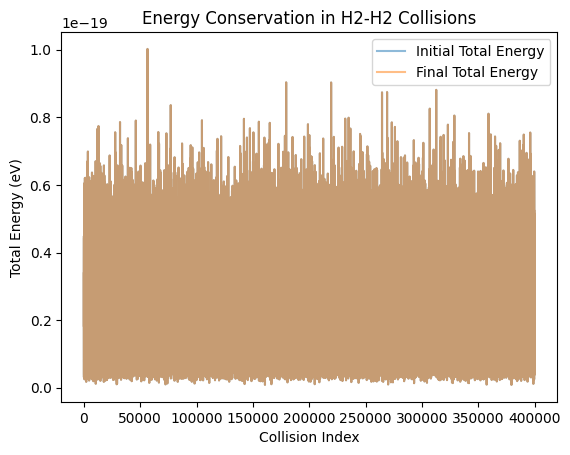

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
# Check energy conservation
file = "data/O2O2_collisions.csv"
df = pd.read_csv(file, skiprows=1)
Etot_init = df.iloc[:,0] + df.iloc[:,1] + df.iloc[:,2]
Etot_final = df.iloc[:,3] + df.iloc[:,4] + df.iloc[:,5]
plt.plot(Etot_init, label='Initial Total Energy', alpha=0.5)
plt.plot(Etot_final, label='Final Total Energy', alpha=0.5)
plt.xlabel('Collision Index')
plt.ylabel('Total Energy (eV)')
plt.title('Energy Conservation in H2-H2 Collisions')
plt.legend()
plt.show()


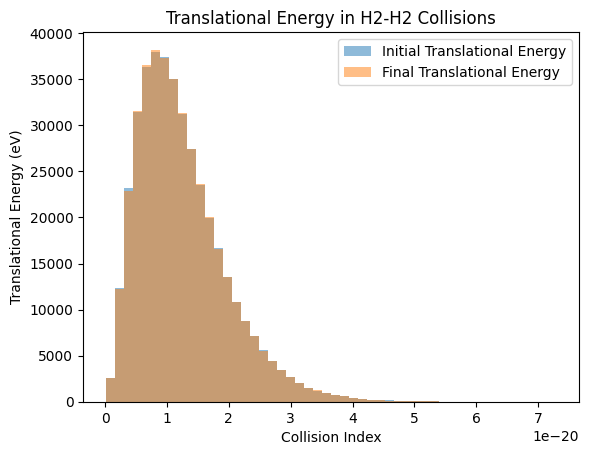

In [12]:
Etr_init = df.iloc[:,0]
Etr_final = df.iloc[:,3]
plt.hist(Etr_init, bins=50, alpha=0.5, label='Initial Translational Energy')
plt.hist(Etr_final, bins=50, alpha=0.5, label='Final Translational Energy')
plt.xlabel('Collision Index')
plt.ylabel('Translational Energy (eV)')
plt.title('Translational Energy in H2-H2 Collisions')
plt.legend()
plt.show()

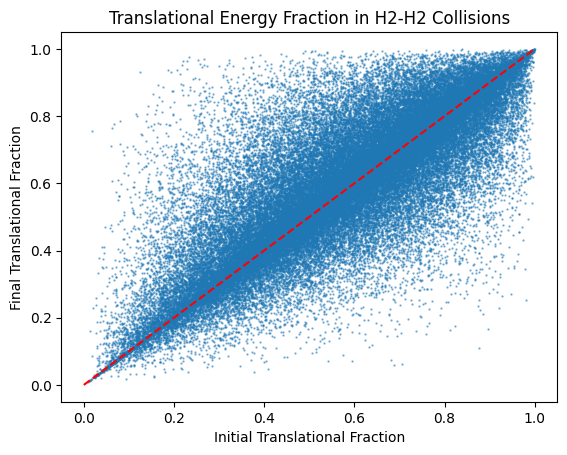

In [13]:
# Plot translational fraction in vs out
Eta_tr_init = Etr_init / Etot_init
Eta_tr_final = Etr_final / Etot_final
plt.scatter(Eta_tr_init, Eta_tr_final, alpha=0.5, s=0.5)
plt.xlabel('Initial Translational Fraction')
plt.ylabel('Final Translational Fraction')
plt.title('Translational Energy Fraction in H2-H2 Collisions')
plt.plot([0, 1], [0, 1], 'r--')
plt.show()

/home/tqz/Documents/University/Master Thesis/scatteringkernels/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


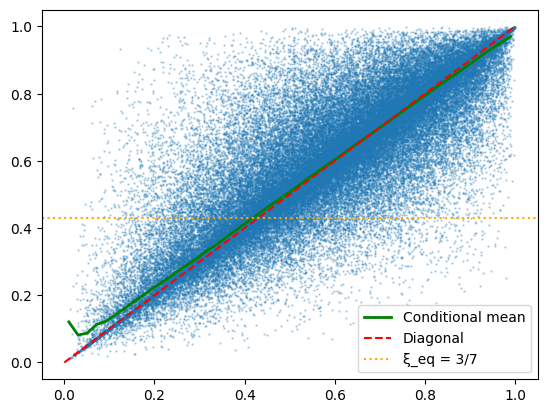

In [14]:
import numpy as np

bins = np.linspace(0, 1, 50)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
digitized = np.digitize(Eta_tr_init, bins)

means = []
for b in range(1, len(bins)):
    mask = digitized == b
    if mask.sum() > 0:
        means.append(Eta_tr_final[mask].mean())
    else:
        means.append(np.nan)

plt.scatter(Eta_tr_init, Eta_tr_final, alpha=0.3, s=0.5)
plt.plot(bin_centers, means, 'g-', linewidth=2, label='Conditional mean')
plt.plot([0, 1], [0, 1], 'r--', label='Diagonal')
plt.axhline(3/7, color='orange', linestyle=':', label='ξ_eq = 3/7')
plt.legend()
plt.show()

This indicates the energy distribution nudges toward equilibrium over many collisions.

/tmp/ipykernel_94734/398923660.py:78: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_94734/398923660.py:79: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("results/plots/ctc_vs_mdn_xi_rel.png", dpi=300)


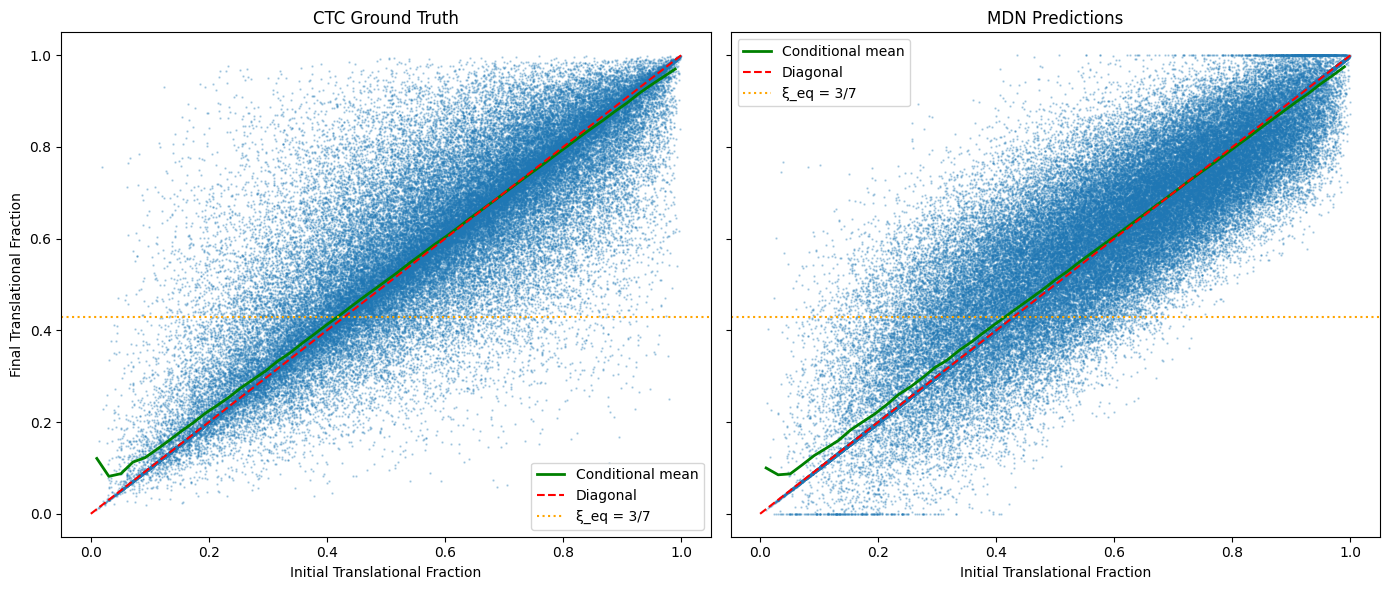

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from machinelearning.mdn import MixtureDensityNetwork
from config.experiment_config import ExperimentConfig

experiment_config = ExperimentConfig()

datafile = "data/O2O2_collisions.csv"
mdn = MixtureDensityNetwork(
    input_dim=3, output_dim=2, num_mixtures=5, hidden_dim=experiment_config.hidden_dim, randomseed=42
)
mdn.load_model("results/models/mdn_O2O2.pth")

# Load CTC data
df = pd.read_csv(datafile)
Etr_init = df["Etr"].values
Erot1_init = df["Erot1_in"].values
Erot2_init = df["Erot2_in"].values
E_available = Etr_init + Erot1_init + Erot2_init

# COM-frame fractions (matching batch_collide input format)
xi_rel = np.where(E_available > 0, Etr_init / E_available, 0.0)
xi_rot_A = np.where(E_available > 0, Erot1_init / E_available, 0.0)

# Build MDN input: [E_available, xi_rel, xi_rot_A]
input_features = torch.tensor(
    np.stack([E_available, xi_rel, xi_rot_A], axis=1), dtype=torch.float32
)

# Sample post-collision fractions from MDN
samples = mdn.sample(input_features).detach().cpu().numpy()
xi_rel_post = np.clip(samples[:, 0], 0.0, 1.0)

# Binned conditional means
bins = np.linspace(0, 1, 50)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
digitized = np.digitize(xi_rel, bins)

means_ctc = []
means_mdn = []
# CTC ground truth fractions
Etr_out = df["Etr_out"].values
Erot1_out = df["Erot1_out"].values
Erot2_out = df["Erot2_out"].values
E_available_out = Etr_out + Erot1_out + Erot2_out
xi_rel_out_ctc = np.where(E_available_out > 0, Etr_out / E_available_out, 0.0)

for b in range(1, len(bins)):
    mask = digitized == b
    if mask.sum() > 0:
        means_ctc.append(xi_rel_out_ctc[mask].mean())
        means_mdn.append(xi_rel_post[mask].mean())
    else:
        means_ctc.append(np.nan)
        means_mdn.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# CTC plot
axes[0].scatter(xi_rel, xi_rel_out_ctc, alpha=0.3, s=0.5)
axes[0].plot(bin_centers, means_ctc, "g-", linewidth=2, label="Conditional mean")
axes[0].plot([0, 1], [0, 1], "r--", label="Diagonal")
axes[0].axhline(3 / 7, color="orange", linestyle=":", label="ξ_eq = 3/7")
axes[0].set_xlabel("Initial Translational Fraction")
axes[0].set_ylabel("Final Translational Fraction")
axes[0].set_title("CTC Ground Truth")
axes[0].legend()

# MDN plot
axes[1].scatter(xi_rel, xi_rel_post, alpha=0.3, s=0.5)
axes[1].plot(bin_centers, means_mdn, "g-", linewidth=2, label="Conditional mean")
axes[1].plot([0, 1], [0, 1], "r--", label="Diagonal")
axes[1].axhline(3 / 7, color="orange", linestyle=":", label="ξ_eq = 3/7")
axes[1].set_xlabel("Initial Translational Fraction")
axes[1].set_title("MDN Predictions")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/plots/ctc_vs_mdn_xi_rel.png", dpi=300)
plt.show()

In [6]:
from visualization.plot import Plotter
from utils.helpers import load_dataset
from machinelearning.mdn_model import MixtureDensityNetwork
from machinelearning.gmm_model import GaussianMixtureModel
from config.experiment_config import ExperimentConfig
config = ExperimentConfig()

# Load CTC dataset
ctc_data = load_dataset("data/H2H2_collisions.csv")

# Sample MDN
mdn = MixtureDensityNetwork(input_dim=config.input_dim, output_dim=config.output_dim, num_mixtures=config.num_mixtures, hidden_dim=config.hidden_dim, randomseed=config.random_seed) 
mdn.load_model("results/models/mdn_H2H2.pth")
mdn_samples = mdn.sample(x=ctc_data[0])

# Sample GMM
gmm = GaussianMixtureModel(n_components=config.gmm_n_components, covariance_type=config.gmm_covariance_type)
gmm.fit(ctc_data[1])
gmm_samples = gmm.sample(num_samples=config.num_samples)

datasets = {
    "inputs": ctc_data[0][:,1:], # Use only the energy fractions for plotting not the total energy
    "CTC": ctc_data[1],
    "MDN": mdn_samples,
    "GMM": gmm_samples
}

ImportError: cannot import name 'Plotter' from 'visualization.plot' (/home/tqz/Documents/University/Master Thesis/scatteringkernels/visualization/plot.py)

In [ ]:
from visualization.plot import Plotter
from config.plotting_config import PlottingConfig
plotting_config = PlottingConfig()
plotter = Plotter(config=plotting_config)
plotter.plot_density_scatter(datasets=datasets)
plotter.plot_histogram(datasets=datasets)

In [ ]:
from analysis.kl_divergence import kl_divergence

kl_ctc_mdn = kl_divergence(datasets["CTC"][0], datasets["MDN"][0])
kl_ctc_gmm = kl_divergence(datasets["CTC"][0], datasets["GMM"][0])
print(f"KL Divergence between CTC and MDN: {kl_ctc_mdn:.4f}")
print(f"KL Divergence between CTC and GMM: {kl_ctc_gmm:.4f}")

KL Divergence between CTC and MDN: -0.5497
KL Divergence between CTC and GMM: -0.4806


/home/tqz/Documents/University/Master Thesis/MEP_TijnZeelenberg/scatteringkernels/analysis/kl_divergence.py:17: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  return kl_div(p, q, reduction='mean')


### DSMC testing

In [ ]:
from physics.dsmc import DSMC_Simulation

Dsmc = DSMC_Simulation()

Dsmc.initialize_domain(box_size=10.0, nr_cells=10, boundary="specular")

Dsmc.initialize_particles(nr_molecules=1000, nr_particles=10, temperature=300.0)

print("cell_indices", Dsmc.cell_indices)

Dsmc.select_collision_pairs()


cell_indices [4 7 5 0 4 7 8 0 7 8]
particle_idx [3 7]
pairs []
particle_idx []
particle_idx []
particle_idx []
particle_idx [0 4]
pairs []
particle_idx [2]
particle_idx []
particle_idx [1 5 8]
pairs []
particle_idx [6 9]
pairs []
particle_idx []
